<a href="https://colab.research.google.com/github/enriquefroes/reforcos-galo-cruzeiro-2026/blob/main/notebooks/04_balanco_janelas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_reforcos_galo_cruzeiro'
except ImportError:
    BASE = './analise_reforcos_galo_cruzeiro'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)
for arq in ['transferencias.csv', 'estatisticas.csv', 'pares.csv']:
    if not os.path.exists(os.path.join(DADOS, arq)):
        raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb')
transf = pd.read_csv(os.path.join(DADOS, 'transferencias.csv'))
est = pd.read_csv(os.path.join(DADOS, 'estatisticas.csv'))
pares = pd.read_csv(os.path.join(DADOS, 'pares.csv'))

PESOS = {'nota': 0.5, 'metricas': 0.3, 'titularidade': 0.2}
MIN_MINUTOS = 450
GRUPO = {'ATA': 'Ataque', 'PD/PE': 'Ataque', 'MC': 'Meio-campo', 'MEI': 'Meio-campo',
         'LD': 'Laterais', 'LE': 'Laterais', 'ZAG': 'Zagueiros', 'GOL': 'Goleiros'}
METRICAS = {
    'Ataque':     ['GA_90', 'xGxA_90', 'passes_decisivos_90', 'dribles_certos_90'],
    'Meio-campo': ['GA_90', 'passes_decisivos_90', 'passes_certos_90', 'desarmes_90', 'interceptacoes_90'],
    'Laterais':   ['GA_90', 'passes_decisivos_90', 'cruzamentos_certos_90', 'desarmes_90', 'interceptacoes_90'],
    'Zagueiros':  ['desarmes_90', 'interceptacoes_90', 'chutes_bloqueados_90', 'duelos_aereos_vencidos_90', 'passes_certos_90'],
    'Goleiros':   ['gols_evitados_90', 'jogos_sem_sofrer_gol_pct'],
}
CORES_CLUBE = {'Atlético-MG': '#111111', 'Cruzeiro': '#1d4ed8'}
SIGLA = {'Atlético-MG': 'CAM', 'Cruzeiro': 'CRU'}

def percentil(s):
    """Posição relativa de 0 (pior) a 1 (melhor) dentro do grupo de referência."""
    s = s.dropna()
    if len(s) < 2:
        return pd.Series(0.5, index=s.index)
    return (s.rank(method='average') - 1) / (len(s) - 1)

def preparar(est, transf):
    d = est.merge(transf[['clube', 'movimento', 'jogador', 'janela', 'operacao', 'valor_milhoes_euros']],
                  on=['clube', 'movimento', 'jogador'], how='left')
    n = d['minutos'] / 90
    d['grupo'] = d['posicao'].map(GRUPO)
    d['GA'] = d['gols'].fillna(0) + d['assistencias'].fillna(0)
    d['GA_90'] = d['GA'] / n
    d['xGxA_90'] = (d['xg'] + d['xa'].fillna(0)) / n
    for c in ['passes_decisivos', 'dribles_certos', 'passes_certos', 'cruzamentos_certos', 'desarmes',
              'interceptacoes', 'chutes_bloqueados', 'duelos_aereos_vencidos', 'gols_evitados']:
        d[c + '_90'] = d[c] / n
    d['jogos_sem_sofrer_gol_pct'] = d['jogos_sem_sofrer_gol'] / d['jogos']
    d['nota_media'] = (d['nota_sofascore'] + d['nota_fotmob']) / 2
    d['min_por_jogo'] = d['minutos'] / d['jogos']
    d['titularidade'] = (d['min_por_jogo'] / 90).clip(upper=1)

    ref = d['minutos'] >= MIN_MINUTOS
    d['p_nota'] = np.nan
    d['p_metricas'] = np.nan
    for g, cols in METRICAS.items():
        idx = d.index[ref & (d['grupo'] == g)]
        d.loc[idx, 'p_nota'] = percentil(d.loc[idx, 'nota_media'])
        pcts = pd.concat([percentil(d.loc[idx, c]) for c in cols], axis=1)
        d.loc[idx, 'p_metricas'] = pcts.mean(axis=1)
    d['score'] = 100 * (PESOS['nota'] * d['p_nota'] + PESOS['metricas'] * d['p_metricas']
                        + PESOS['titularidade'] * d['titularidade'])
    d.loc[~ref, 'score'] = np.nan
    d['n_ref_grupo'] = d['grupo'].map(d[ref].groupby('grupo').size())
    return d

df = preparar(est, transf)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


In [2]:
t = transf.copy()
t['valor'] = t['valor_milhoes_euros'].fillna(0)
t['efetivacao'] = t['operacao'].str.contains('efetivação|após empréstimo|repassado', na=False)
resumo = (t.groupby(['clube', 'movimento', 'janela'])['valor'].sum().unstack(['movimento', 'janela']).fillna(0))
bal = pd.DataFrame({
    'pago_janeiro': resumo[('chegada', 'janeiro')], 'pago_meio': resumo[('chegada', 'meio do ano')],
    'recebido_janeiro': resumo[('saída', 'janeiro')], 'recebido_meio': resumo[('saída', 'meio do ano')]})
bal['pago_total'] = bal['pago_janeiro'] + bal['pago_meio']
bal['recebido_total'] = bal['recebido_janeiro'] + bal['recebido_meio']
bal['saldo'] = bal['recebido_total'] - bal['pago_total']
bal['pago_em_efetivacoes'] = t[t['efetivacao'] & (t['movimento'] == 'chegada')].groupby('clube')['valor'].sum()
bal['recebido_em_efetivacoes'] = t[t['efetivacao'] & (t['movimento'] == 'saída')].groupby('clube')['valor'].sum()
bal = bal.fillna(0).round(2)
bal.to_csv(os.path.join(TAB, '04_balanco_janelas.csv'))
bal

,pago_janeiro,pago_meio,recebido_janeiro,recebido_meio,pago_total,recebido_total,saldo,pago_em_efetivacoes,recebido_em_efetivacoes
clube,,,,,,,,,
Atlético-MG,22.15,5.50,17.27,0.0,27.65,17.27,-10.38,3.5,8.85
Cruzeiro,27.85,23.85,0.86,28.9,51.70,29.76,-21.94,3.7,0.86


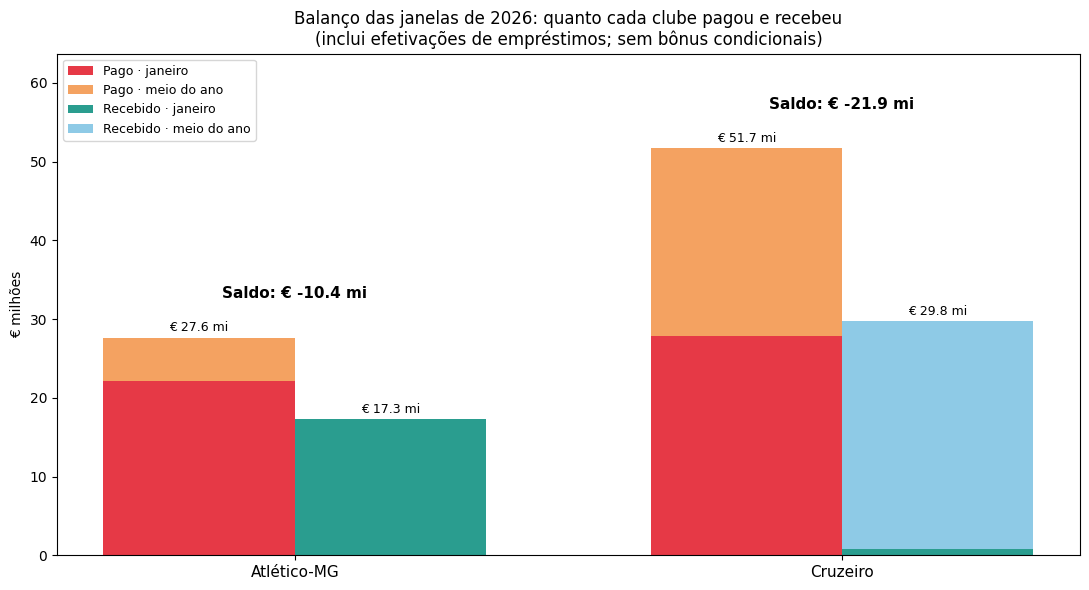

Salvo em /content/drive/MyDrive/analise_reforcos_galo_cruzeiro/graficos/04a_balanco_janelas.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(bal))
w = 0.35
ax.bar(x - w/2, bal['pago_janeiro'], w, color='#e63946', label='Pago · janeiro')
ax.bar(x - w/2, bal['pago_meio'], w, bottom=bal['pago_janeiro'], color='#f4a261', label='Pago · meio do ano')
ax.bar(x + w/2, bal['recebido_janeiro'], w, color='#2a9d8f', label='Recebido · janeiro')
ax.bar(x + w/2, bal['recebido_meio'], w, bottom=bal['recebido_janeiro'], color='#8ecae6', label='Recebido · meio do ano')
for i, (pg, rc, s) in enumerate(zip(bal['pago_total'], bal['recebido_total'], bal['saldo'])):
    ax.text(i - w/2, pg + 0.8, f'€ {pg:.1f} mi', ha='center', fontsize=9)
    ax.text(i + w/2, rc + 0.8, f'€ {rc:.1f} mi', ha='center', fontsize=9)
    ax.text(i, max(pg, rc) + 5, f'Saldo: € {s:+.1f} mi', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bal.index, fontsize=11)
ax.set_ylabel('€ milhões')
ax.set_ylim(0, bal[['pago_total', 'recebido_total']].values.max() + 12)
ax.set_title('Balanço das janelas de 2026: quanto cada clube pagou e recebeu\n(inclui efetivações de empréstimos; sem bônus condicionais)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
salvar('04a_balanco_janelas.png')